# 1) Implement simple and multiple linear regression using Numpy and using Scikit-learn .Ploat regression line and residuals. Compute RMSE and R2 values

## 1) IMPORT LIBRARIES

In [45]:
# import required Labraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

## 2)DATA COLLECTION 

In [46]:
#Create the dataset 

data = {
    "Study_Hours" : [1,2,3,4,5,6,7,8,9,10],
    "Attendance" : [60,85,70,95,65,80,90,75,88,72],
    "Marks" : [32,42,47,58,61,67,76,79,88,91]
}

#Convert dict into DataFrame 
df = pd.DataFrame(data)
print(df)

   Study_Hours  Attendance  Marks
0            1          60     32
1            2          85     42
2            3          70     47
3            4          95     58
4            5          65     61
5            6          80     67
6            7          90     76
7            8          75     79
8            9          88     88
9           10          72     91


## 3) EDA And Preprocessing 

In [47]:
print('Fidrst Five Rows:')
df.head()

Fidrst Five Rows:


,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61


In [48]:
print('Shape of Dataset:')
df.shape

Shape of Dataset:


(10, 3)

In [49]:
print('Information :')
df.info()

Information :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Study_Hours  10 non-null     int64
 1   Attendance   10 non-null     int64
 2   Marks        10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


In [50]:
print('Statistical Analysis :\n', df.describe())

Statistical Analysis :
        Study_Hours  Attendance      Marks
count     10.00000   10.000000  10.000000
mean       5.50000   78.000000  64.100000
std        3.02765   11.489125  19.790289
min        1.00000   60.000000  32.000000
25%        3.25000   70.500000  49.750000
50%        5.50000   77.500000  64.000000
75%        7.75000   87.250000  78.250000
max       10.00000   95.000000  91.000000


In [51]:
print('Check for null values:')
df.isnull().sum()

Check for null values:


Study_Hours    0
Attendance     0
Marks          0
dtype: int64

In [52]:
# Duplicate Values
df.duplicated().sum()

np.int64(0)

In [53]:
df.drop_duplicates()

,Study_Hours,Attendance,Marks
0,1,60,32
1,2,85,42
2,3,70,47
3,4,95,58
4,5,65,61
5,6,80,67
6,7,90,76
7,8,75,79
8,9,88,88
9,10,72,91


# Data Visulation 

In [54]:
# correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

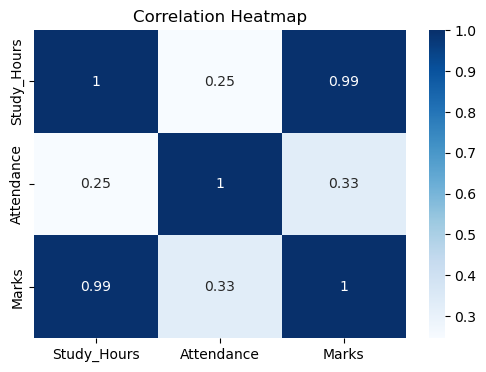

In [55]:
import seaborn as sns

df_corr = df.corr()

plt.figure(figsize = (6,4))
sns.heatmap(df_corr , annot = True , cmap ='Blues')

plt.title('Correlation Heatmap')

# A) Simple Linear Regression By Using Sckit-learn

In [56]:
#feacture Selection 
x=df[['Study_Hours']]   #Independent Variable
y=df['Marks']           # Dependent variable

# 4) Module Building

In [58]:
# Split Dataset into traning and testing set 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.3 , random_state=42)

In [59]:
x_test

,Study_Hours
8,9
1,2
5,6


In [61]:
# Import Model 
from sklearn.linear_model import LinearRegression
model = LinearRegression()

#Train the model
model.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
# predict the Values
y_pred=model.predict(x_test)
y_pred

array([86.55445545, 41.22772277, 67.12871287])

In [64]:
# Print Equation 
print('Intercet:' , model.intercept_)
print('Slope :' , model.coef_[0])

Intercet: 28.277227722772274
Slope : 6.475247524752477


## SLR Equation 

• Marks=(6.48*Study_Hours)+28.27

# 5) Model Evoulation

In [65]:
#EvaLluation

from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2= r2_score(y_test, y_pred)

In [66]:
print('RSME:', round(rmse, 3))
print('R2 Score:', round(r2, 2))

RSME: 0.949
R2 Score: 1.0


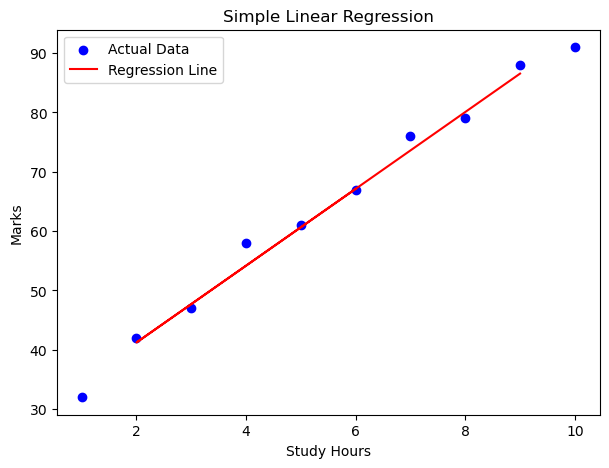

In [69]:
# Regression Line

plt.figure(figsize=(7, 5))
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, y_pred,
        color='red',
        label='Regression Line')

plt.xlabel('Study Hours')
plt.ylabel('Marks')

plt.title('Simple Linear Regression' )
plt.legend()

plt.show()

## Residual Plot

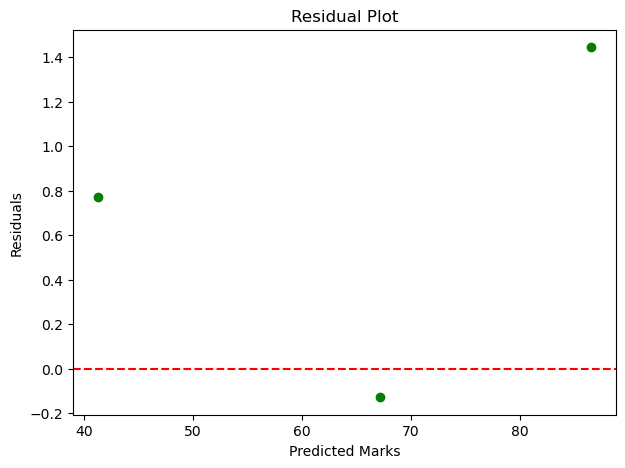

In [70]:
residuals = y_test - y_pred # Calculate Residual

plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, color='green')
plt.axhline(y=0,

color='red',

linestyle="--")
plt.xlabel('Predicted Marks')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

# B) Simple Linear Regression by using Numpy

In [71]:
# Independent Variable (Features)
x = df["Study_Hours"].values

# Dependent Variable (Target)
y = df["Marks"].values

In [72]:
# Calculate mean
x_mean = np.mean(x)
y_mean = np.mean(y)

In [73]:
# Calculate slope
m = np.sum((x-x_mean)*(y-y_mean) )/np.sum((x-x_mean) **2)

# Calculate intercept
b = y_mean - m*x_mean
print("Slope =", m)
print("Intercept =", b)

Slope = 6.503030303030303
Intercept = 28.33333333333333


In [74]:
# Prediction
y_pred_numpy = m*x + b
y_pred_numpy

array([34.83636364, 41.33939394, 47.84242424, 54.34545455, 60.84848485,
       67.35151515, 73.85454545, 80.35757576, 86.86060606, 93.36363636])

# Multiple Linear Regression

In [78]:
# Feature Selection
x = df[['Study_Hours', 'Attendance']] # Independent Variables
y=df['Marks'] # Dependent Variable

# Split Dataset
x_train, x_test, y_train, y_test =train_test_split(x, y, test_size=0.3, random_state=42)

# Model Building

In [79]:
model=LinearRegression()
model. fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [80]:
# Prediction
y_pred =model.predict(x_test)
y_pred

array([88.08653885, 43.59718321, 67.84336712])

In [85]:
# Model Parameters
print('Intercept:', model.intercept_)
print("Coefficients", )
coeff=pd.DataFrame({
'Feature': x.columns,
'Coefficient': model.coef_

})

print (coeff)

Intercept: 16.144584198314774
Coefficients
       Feature  Coefficient
0  Study_Hours     6.280539
1   Attendance     0.175194


## MLR Equation
• Marks=(6.29Study_ Hours) + (0.18 Attendance) + 16.15

# Model Evalution

In [86]:
# Evaluation Metrics

print('Metrics Values of MLR:')

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', round(rmse, 2))

print('R2 Score:', round(r2, 2))

Metrics Values of MLR:
RMSE: 1.04
R2 Score: 1.0


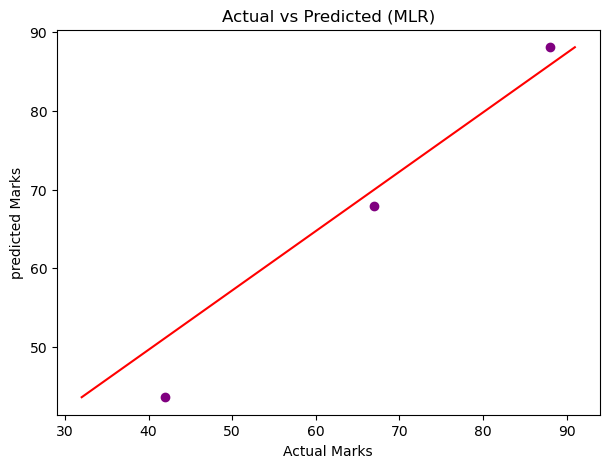

In [89]:
# Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='Purple' )

# Perfect Prediction Line
plt.plot([y.min(), y.max()],
         [y_pred.min(), y_pred.max()],
color='red')

plt.xlabel( 'Actual Marks')
plt.ylabel("predicted Marks")
plt.title('Actual vs Predicted (MLR)')
plt.show()